# Data Loading and Preparation

In [1]:
import pandas as pd

df = pd.read_csv("data/german.data", sep=" ", header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [2]:
df = pd.read_csv("data/german.data", sep=" ", header=None)
df.shape

(1000, 21)

In [5]:
columns = [
    "checking_account",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_years",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_years",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "num_dependents",
    "telephone",
    "foreign_worker",
    "target"
]

df.columns = columns
df.head()

,checking_account,duration_months,credit_history,purpose,credit_amount,savings_account,employment_years,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,num_dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
df["target"] = df["target"].map({1: 0, 2: 1})
df["target"].value_counts()

target
0    700
1    300
Name: count, dtype: int64

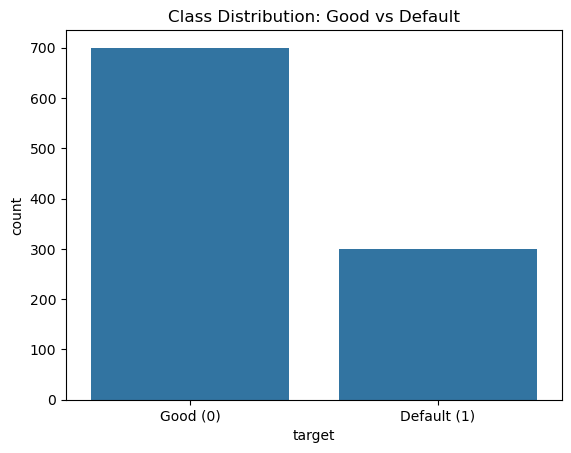

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df["target"])
plt.title("Class Distribution: Good vs Default")
plt.xticks([0,1], ["Good (0)", "Default (1)"])
plt.show()

In [8]:
cost_fn = 5   # Default predicted as good
cost_fp = 1   # Good predicted as default

In [9]:
df.dtypes

checking_account           object
duration_months             int64
credit_history             object
purpose                    object
credit_amount               int64
savings_account            object
employment_years           object
installment_rate            int64
personal_status_sex        object
other_debtors              object
residence_years             int64
property                   object
age                         int64
other_installment_plans    object
housing                    object
existing_credits            int64
job                        object
num_dependents              int64
telephone                  object
foreign_worker             object
target                      int64
dtype: object

In [10]:
X = df.drop("target", axis=1)
y = df["target"]


In [11]:
numeric_features = [
    "duration_months",
    "credit_amount",
    "installment_rate",
    "residence_years",
    "age",
    "existing_credits",
    "num_dependents"
]

categorical_features = [
    col for col in X.columns if col not in numeric_features
]


In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [14]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['duration_months', 'credit_amount',
                                  'installment_rate', 'residence_years', 'age',
                                  'existing_credits', 'num_dependents']),
                                ('cat', OneHotEncoder(drop='first'),
                                 ['checking_account', 'credit_history',
                                  'purpose', 'savings_account',
                                  'employment_years', 'personal_status_sex',
                                  'other_debtors', 'property',
                                  'other_installment_plans', 'housing', 'job',
                                  'telephone', 'foreign_worker'])])

# Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [16]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [17]:
from sklearn.model_selection import cross_val_score

roc_scores = cross_val_score(
    log_model,
    X,
    y,
    cv=skf,
    scoring="roc_auc"
)

roc_scores.mean()

0.7860238095238096

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix

cost_fn = 5  # false negative cost
cost_fp = 1  # false positive cost

def compute_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    return total_cost

In [19]:
from sklearn.model_selection import cross_val_predict

y_prob = cross_val_predict(
    log_model,
    X,
    y,
    cv=skf,
    method="predict_proba"
)[:,1]

In [20]:
thresholds = np.linspace(0, 1, 100)
costs = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    cost = compute_cost(y, y_pred)
    costs.append(cost)

min_cost = min(costs)
optimal_threshold = thresholds[np.argmin(costs)]

min_cost, optimal_threshold

(537, 0.13131313131313133)

In [21]:
baseline_cost = 300 * 5
reduction = (baseline_cost - 537) / baseline_cost
reduction

0.642

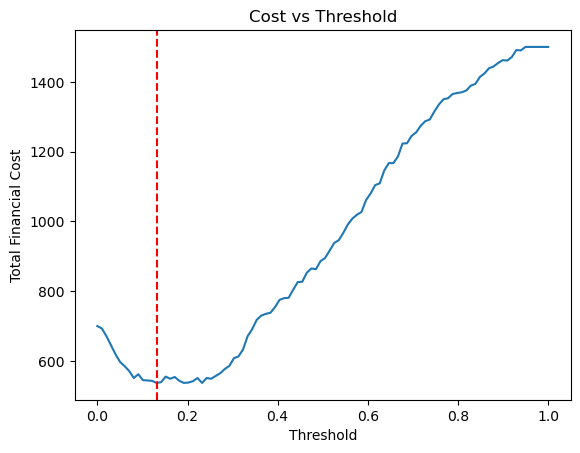

In [22]:
import matplotlib.pyplot as plt

plt.plot(thresholds, costs)
plt.axvline(optimal_threshold, color='r', linestyle='--')
plt.title("Cost vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Total Financial Cost")
plt.show()

In [23]:
# Default threshold = 0.5
y_pred_default = (y_prob >= 0.5).astype(int)
cost_default = compute_cost(y, y_pred_default)

cost_default

890

In [24]:
(cost_default - min_cost) / cost_default

0.39662921348314606

In [25]:
from sklearn.metrics import confusion_matrix

y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

cm = confusion_matrix(y, y_pred_optimal)
cm

array([[298, 402],
       [ 27, 273]], dtype=int64)

In [26]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 298
False Positives: 402
False Negatives: 27
True Positives: 273


In [27]:
from sklearn.metrics import precision_score, recall_score

precision = precision_score(y, y_pred_optimal)
recall = recall_score(y, y_pred_optimal)

precision, recall

(0.40444444444444444, 0.91)